In [1]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Reshape, Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import PolynomialDecay
from tensorflow.keras.models import Model
import kerastuner as kt

from tensorflow.keras.callbacks import EarlyStopping

import os
import re
import glob
import sys

from pathlib import Path
parentdir = os.path.dirname(os.getcwd())
sys.path.insert(0, parentdir)

import OptimizedDataGenerator4 as ODG


# ─── 2) Setup data generators ────────────────────────────────────────────────
BASE_DIR        = Path("/home/youeric/PixelML/smart_pixels_ml/filtering_models/filtering_records2000")
TRAIN_DIR       = BASE_DIR / "tfrecords_train"
VALIDATION_DIR  = BASE_DIR / "tfrecords_validation"

train_gen = ODG.OptimizedDataGenerator(
    load_records           = True,
    tf_records_dir         = str(TRAIN_DIR),
    x_feature_description  = ['cluster', 'y_local','z_global']
)

val_gen = ODG.OptimizedDataGenerator(
    load_records           = True,
    tf_records_dir         = str(VALIDATION_DIR),
    x_feature_description  = ['cluster','y_local','z_global']
)

2025-07-26 18:49:47.378915: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-26 18:49:47.392919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753573787.408014 2796686 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753573787.412753 2796686 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753573787.424366 2796686 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
def model_builder(hp):
    # ── A) Polynomial‐decay hyperparams ─────────────────────────────────────
    initial_lr = hp.Float("initial_lr", 1e-4, 1e-2, sampling="log")
    end_lr     = hp.Float("end_lr",     1e-6, 1e-4, sampling="log")
    power      = hp.Float("poly_power", 0.5, 2.5, step=0.5)

    decay_steps = len(train_gen) * 200
    lr_schedule = PolynomialDecay(
        initial_learning_rate = initial_lr,
        decay_steps           = decay_steps,
        end_learning_rate     = end_lr,
        power                 = power
    )
    optimizer = Adam(learning_rate=lr_schedule)

    # ── B) Architecture hyperparams ──────────────────────────────────────────
    f1           = hp.Int("conv_filters", 16, 64, step=16)
    # separately tune rows and cols
    k_rows       = hp.Choice("kernel_rows", [3, 5, 7, 9])
    k_cols       = hp.Choice("kernel_cols", [3, 5, 7, 9])
    z_units      = hp.Int("z_units",      8, 64, step=8)
    y_units      = hp.Int("y_units",      8, 64, step=8)
    head_units   = hp.Int("head_units",  32,256, step=64)
    drop_rate    = hp.Float("dropout",     0.0, 0.8, step=0.1)

    # ── C) Inputs ─────────────────────────────────────────────────────────────
    vol_input = Input(shape=(13, 21), name="cluster")
    z_input   = Input(shape=(1,),     name="z_global")
    y_input   = Input(shape=(1,),     name="y_local")

    # ── D) Conv2D branch with rectangular kernel ─────────────────────────────
    x = Reshape((13, 21, 1), name="add_channel")(vol_input)
    x = Conv2D(
        filters=f1,
        kernel_size=(k_rows, k_cols),
        padding="same",
        activation="relu",
        name=f"conv2d_{k_rows}x{k_cols}"
    )(x)
    x = MaxPooling2D((2, 2), name="pool2d_1")(x)
    x = Flatten(name="flatten_vol")(x)

    # ── E) Scalar branches ───────────────────────────────────────────────────
    z_dense = Dense(z_units, activation="relu", name="dense_z")(z_input)
    y_dense = Dense(y_units, activation="relu", name="dense_y")(y_input)

    # ── F) Merge & head ──────────────────────────────────────────────────────
    merged = Concatenate(name="concat_all")([x, z_dense, y_dense])
    h = Dense(head_units, activation="relu", name="head_dense1")(merged)
    h = Dropout(drop_rate,     name="head_dropout")(h)
    h = Dense(head_units // 2, activation="relu", name="head_dense2")(h)

    output = Dense(1, activation="sigmoid", name="output")(h)

    model = Model(
        [vol_input, z_input, y_input],
        output,
        name="rect_kernel_conv2d_with_y"
    )
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [3]:
# ─── 3) Instantiate the Tuner ──────────────────────────────────────────────
tuner = kt.RandomSearch(
    model_builder,
    objective           = "val_accuracy",
    max_trials          = 120,
    executions_per_trial= 2,
    directory           = "ktuner_dir",
    project_name        = "conv3d_zsearch"
)

I0000 00:00:1753573799.963326 2796686 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14283 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:4b:00.0, compute capability: 8.6


In [7]:
# ─── 4) Run the hyperparameter search ─────────────────────────────────────
tuner.search(
    train_gen,
    validation_data = val_gen,
    epochs          = 110,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

Epoch 1/110


2025-07-26 20:09:26.869387: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at xla_ops.cc:591 : INTERNAL: ptxas exited with non-zero error code 2, output: 
2025-07-26 20:09:26.869427: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INTERNAL: ptxas exited with non-zero error code 2, output: 
	 [[{{node StatefulPartitionedCall}}]]


KeyboardInterrupt: 

In [5]:
# ─── 5) Retrieve best HPs and model ───────────────────────────────────────
best_hp    = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

print("🔎 Best hyperparameters:")
for hp_name in ["initial_lr","end_lr","poly_power",
                "conv1_filters","conv2_filters",
                "z_units","head_units","dropout"]:
    print(f" • {hp_name}: {best_hp.get(hp_name)}")

/home/youeric/miniconda3/envs/mlgpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 25 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "rect_kernel_conv2d_with_y"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cluster             │ (None, 13, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_channel         │ (None, 13, 21, 1) │          0 │ cluster[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5x9 (Conv2D) │ (None, 13, 21,    │      1,472 │ add_channel[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2d_1            │ (None, 6, 10, 32) │          0 │ conv2d_5x9[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_local             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_vol         │ (None, 1920)      │          0 │ pool2d_1[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_z (Dense)     │ (None, 64)        │        128 │ z_global[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_y (Dense)     │ (None, 8)         │         16 │ y_local[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_all          │ (None, 1992)      │          0 │ flatten_vol[0][0… │
│ (Concatenate)       │                   │            │ dense_z[0][0],    │
│                     │                   │            │ dense_y[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense1 (Dense) │ (None, 224)       │    446,432 │ concat_all[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 224)       │          0 │ head_dense1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense2 (Dense) │ (None, 112)       │     25,200 │ head_dropout[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        113 │ head_dense2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 473,361 (1.81 MB)

 Trainable params: 473,361 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

🔎 Best hyperparameters:
 • initial_lr: 0.00012788498275711674
 • end_lr: 1.2404065397661918e-06
 • poly_power: 1.5


KeyError: 'conv1_filters does not exist.'

In [6]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
fresh_model = model_builder(best_hp)

history_fresh = fresh_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=120,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
    ]
)

# 4) (Optional) inspect final performance
val_loss, val_acc = fresh_model.evaluate(val_gen, verbose=0)
print(f"Final fresh‐train → val_acc: {val_acc:.4f}, val_loss: {val_loss:.4f}")

Epoch 1/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.4703 - loss: 0.7718 - val_accuracy: 0.6507 - val_loss: 0.6467
Epoch 2/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5361 - loss: 0.6968 - val_accuracy: 0.6777 - val_loss: 0.6314
Epoch 3/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6340 - loss: 0.6415 - val_accuracy: 0.6800 - val_loss: 0.6149
Epoch 4/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6202 - loss: 0.6367 - val_accuracy: 0.6773 - val_loss: 0.6106
Epoch 5/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6905 - loss: 0.5993 - val_accuracy: 0.6871 - val_loss: 0.5997
Epoch 6/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6674 - loss: 0.6103 - val_accuracy: 0.6874 - val_loss: 0.5928
Epoch 7/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6599 - loss: 0.5917 - val_accuracy: 0.6542 - val_loss: 0.6157
Epoch 8/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7262 - loss: 0.5680 - val_accuracy: 0

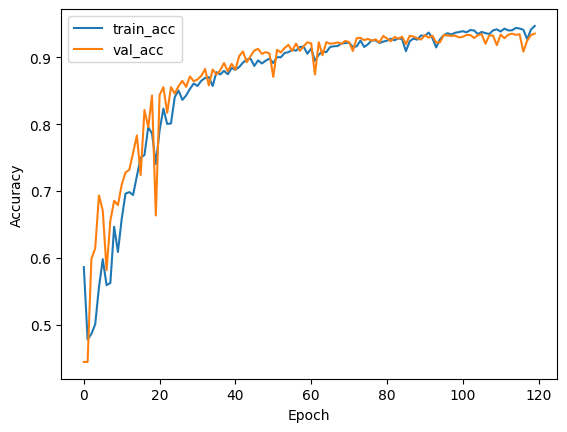

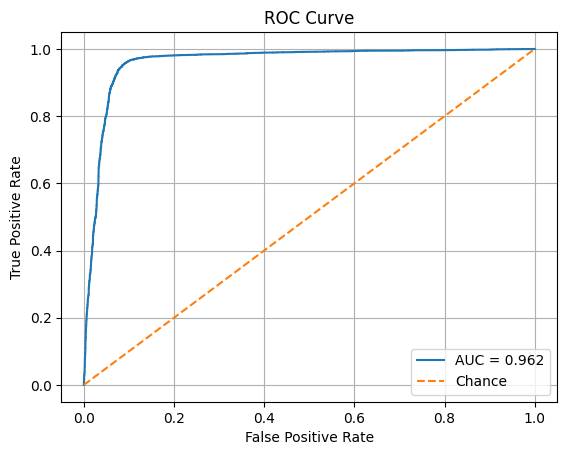

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_fresh.history['accuracy'],    label='train_acc')
plt.plot(history_fresh.history['val_accuracy'],label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 5) ROC Curve — if you meant to score the SAME fresh_model, use that here:
import numpy as np
from sklearn.metrics import roc_curve, auc

y_score = fresh_model.predict(val_gen, verbose=0).ravel()
y_true  = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc     = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

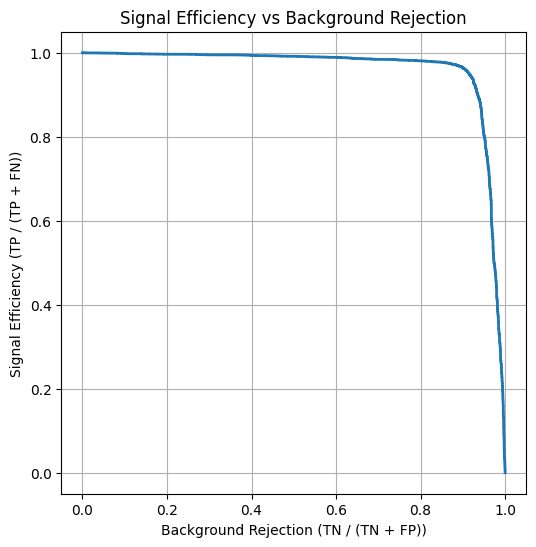

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# 1) Get your scores & labels
y_score = fresh_model.predict(val_gen, verbose=0).ravel()
y_true  = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

# 2) Use roc_curve just to get a sensible set of thresholds
_, _, thresholds = roc_curve(y_true, y_score)

# 3) Loop over each threshold, compute your metrics
signal_efficiencies   = []
background_rejections = []

for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # your definitions:
    sig_eff = tp / (tp + fn)    # TP/(TP+FN)
    bkg_rej = tn / (tn + fp)    # TN/(TN+FP)

    signal_efficiencies.append(sig_eff)
    background_rejections.append(bkg_rej)

# 4) Plot “like‐ROC” curve (Signal Eff vs. Bkg Rej)
plt.figure(figsize=(6,6))
plt.plot(background_rejections, signal_efficiencies, lw=2)
plt.xlabel('Background Rejection (TN / (TN + FP))')
plt.ylabel('Signal Efficiency (TP / (TP + FN))')
plt.title('Signal Efficiency vs Background Rejection')
plt.grid(True)
plt.show()